<a href="https://colab.research.google.com/github/gav-ip/ML-zero/blob/main/makemore_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [3]:
# build mapping of the vocab of string to integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [69]:
# bulid dataset

block_size = 3 # context length: how many chars do we need to predict another one?

X, Y = [], []
for w in words:

  # print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context),'--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [70]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

small notes:\
like in E04 of the first lecture video where it asks us to replace the one_hot encoding function call we can instead just indrectly index the rows of a matrix

In [71]:
# EX: C is our look up table (embedding) for each character
C = torch.randn(27,2)


In [72]:
C[5]

tensor([-0.8643,  0.0733])

In [73]:
# we can also index on multiple rows of C by using a list

C[[5,6,7]]

tensor([[-0.8643,  0.0733],
        [ 1.5371,  1.5837],
        [ 0.4955, -0.7120]])

In [74]:
# or index using a tensor
C [torch.tensor([5,6,7])]

tensor([[-0.8643,  0.0733],
        [ 1.5371,  1.5837],
        [ 0.4955, -0.7120]])

In [75]:
C[X].shape

torch.Size([228146, 3, 2])

In [76]:
X[13,2]

tensor(1)

In [77]:
C[1]

tensor([-0.8115,  0.4569])

In [78]:
C[X][13,2]

tensor([-0.8115,  0.4569])

creating our input layer

In [79]:
# our embedding matrix
emb = C[X]
emb.shape # (96 x 2 layers)

torch.Size([228146, 3, 2])

In [80]:
# number of inputs is 3 * 2 = 6
# 3 dimensional embeddings (block_size)
# 2 (2 columns for the size of C )
W1 = torch.randn(6,100)
b1 = torch.randn(100)

In [81]:
# notice how we can't mat mul the emb matrix due to a dimensionality difference
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (684438x2 and 6x100)

In [ ]:
# indexing each block size
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

In [ ]:
# can also use torch unbind
torch.cat(torch.unbind(emb, 1), 1).shape

In [ ]:
# recommended: using torch.view(), exteremely efficient, no memory is being changed, copied,or removed.
 # emb.view(32, 6).shape

hidden layer implementation

In [ ]:
# hidden layer activation for all 32 examples
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)
# alternatively we can do: torch.tanh(emb.view(-1, 6) @ W1 + b1), pytorch will derive that -1 is 32 (or m size of a matrix)

creating the output layer

In [ ]:
# weight and biases
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [82]:
logits = h @ W2 + b2

In [83]:
# same procedure as doing cross entropy to going into the softmax layer
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([32, 27])

we can clean this up and organize all the params and operations to calculate the loss

In [84]:
# dataset shape
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

bulid dataset split (80/20/10)\
prevents overfitting and helps improve generalization

In [6]:
# bulid dataset
def build_dataset(words):

  block_size = 3 # context length: how many chars do we need to predict another one?
  X, Y = [], []
  for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context),'--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [33]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = 0.1 * torch.randn((6, 300), generator=g)
b1 = 0.1 * torch.randn(300, generator=g)
W2 = 0.1 * torch.randn((300, 27), generator=g)
b2 = 0.1 * torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [165]:
sum(p.nelement() for p in parameters) # num of total params in our NN

10281

In [166]:
for p in parameters:
  p.requires_grad = True

In [167]:
lre = torch.linspace(-2, -1, 30000)
lrs = 10**lre
#  lrs.flip(dims=(0,))

In [168]:
lri = []
lossi = []
stepi = []

In [169]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 300)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

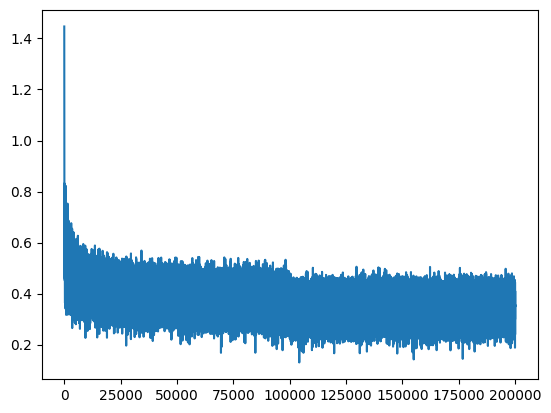

In [170]:
plt.plot(stepi, lossi)

In [171]:
emb = C[Xdev] # (32, 3 ,2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2497, grad_fn=<NllLossBackward0>)

In [172]:
emb = C[Xtr] # (32, 3 ,2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2156, grad_fn=<NllLossBackward0>)

 # Exercises
- E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2

  **easy way to do this is to increase the num of params. Otherwise we can increase the block_size to give more context to the model as well as playing around with the batch size to improve convergence. When increasing the block_size, loss seemed to actually increase (why?, prolly relates to E02) **


- E02: I was not careful with the intialization of the network in this video. (1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? (2) Can you tune the initialization to get a starting loss that is much more similar to (1)?

(1) uniform would mean an equal probability distribution across all 27 classes. so now we would expect an initial loss of -log(-1/27) = 3.29.\
(2) we can tune the initial loss of each weight layer to a scalar that transforms all the initial probabilities close to 0. (e.g 0.1 or 0.01)

- E03: Read the Bengio et al 2003 paper (link above), implement and try any idea from the paper. Did it work?



E03: Using Monte Carlo estimate of the expensive term (softmax)

In [ ]:
# E03: Paper says that softmax normalization is a bottleneck
#      Having to normalize over the entire train split every step becomes
#      computationally expensive.

### Implementing Out-of-Vocabulary (OOV) Word Handling

As described in the Bengio et al. 2003 paper, we can handle out-of-vocabulary words by initializing their feature vector as a weighted convex combination of the feature vectors of known words. The weights are proportional to the conditional probabilities assigned by the network to these known words in the same context.

The formula is: `C(j) ← ∑i∈V C(i)Pˆ(i|wt−1 t−n+1)`

Where:
- `C(j)` is the new feature vector for the OOV word `j`.
- `C(i)` are the existing feature vectors for words `i` in the vocabulary `V`.
- `Pˆ(i|wt−1 t−n+1)` is the conditional probability of word `i` given the context `wt−1 t−n+1`.

In [35]:
# Step 1: Define a sample context and an out-of-vocabulary (OOV) word

# Let's pick a random context from our training data Xtr
context_idx = torch.randint(0, Xtr.shape[0], (1,)).item()
sample_context = Xtr[context_idx].unsqueeze(0) # Unsqueeze to make it a batch of 1

print(f"Sample context (integer IDs): {sample_context.squeeze().tolist()}")
print(f"Sample context (characters): {[itos[i.item()] for i in sample_context.squeeze()]}")

# Simulate an OOV word. For demonstration, we'll imagine a character not in our `stoi`.
# In a real scenario, this would be a word that hasn't appeared in training.
# For character-level model, assume we encountered a new character, e.g., '€', which is not in 'stoi'.
# For simplicity, we will use a hypothetical index that is outside our vocab size for 'j'.
# In practice, 'j' would be a new token assigned a new index and an initially random embedding,
# then refined using the weighted average of existing embeddings.

Sample context (integer IDs): [0, 0, 1]
Sample context (characters): ['.', '.', 'a']


In [36]:
# Step 2: Calculate the predicted probabilities P^(i|wt-1 t-n+1) for the given context

# Get embeddings for the sample context
emb_context = C[sample_context] # (1, block_size, embedding_dim)

# Pass through the hidden layer
h_context = torch.tanh(emb_context.view(-1, 6) @ W1 + b1) # (1, hidden_layer_size)

# Calculate logits
logits_context = h_context @ W2 + b2 # (1, vocab_size)

# Apply softmax to get conditional probabilities P_hat
P_hat = F.softmax(logits_context, dim=1)

print(f"Shape of P_hat (conditional probabilities): {P_hat.shape}")
# print(P_hat) # Uncomment to see the probabilities

Shape of P_hat (conditional probabilities): torch.Size([1, 27])


In [37]:
# Step 3: Compute the initial feature vector C(j) for the OOV word

# The formula is C(j) ← ∑i∈V C(i)Pˆ(i|wt−1 t−n+1)
# This can be efficiently computed as a matrix multiplication: P_hat @ C

# C is our embedding matrix (vocab_size, embedding_dim)
# P_hat is (1, vocab_size)
# Result will be (1, embedding_dim)

C_oov_j = P_hat @ C

print(f"Initial feature vector C(j) for the OOV word: {C_oov_j}")
print(f"Shape of the OOV feature vector: {C_oov_j.shape}")

# This `C_oov_j` can now be used as the initial embedding for the OOV word `j`.
# In a complete implementation, `j` would be added to the vocabulary (`stoi`, `itos`),
# and `C_oov_j` would be appended to the embedding matrix `C`.

Initial feature vector C(j) for the OOV word: tensor([[-0.1283,  0.0381]])
Shape of the OOV feature vector: torch.Size([1, 2])
